<a href="https://colab.research.google.com/github/sandy-ukr/crop-yield-prediction/blob/main/crop.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

# ML imports
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import silhouette_score
from sklearn.ensemble import IsolationForest
from scipy.cluster.hierarchy import dendrogram, linkage

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [ ]:
crop_files = [
    ("apples.csv", "apples"),
    ("apricots.csv", "apricots"),
    ("areca_nuts.csv", "areca nuts"),
    ("bananas.csv", "bananas"),
    ("barley.csv", "barley"),
    ("beans_dry.csv", "beans dry"),
    ("beans_green.csv", "beans green"),
    ("cabbage.csv", "cabbage"),
    ("carrots.csv", "carrots"),
    ("cashewnuts.csv", "cashewnuts"),
    ("cauliflower.csv", "cauliflower"),
    ("cherries.csv", "cherries"),
    ("chilli_dry.csv", "chilli dry"),
    ("chilli_green.csv", "chilli green"),
    ("coconuts.csv", "coconuts"),
    ("coffee.csv", "coffee"),
    ("cucumber.csv", "cucumber"),
    ("eggplant.csv", "eggplant"),
    ("fennel_coriander.csv", "fennel coriander"),
    ("garlic.csv", "garlic"),
    ("ginger.csv", "ginger"),
    ("grapes.csv", "grapes"),
    ("groundnuts.csv", "groundnuts"),
    ("lemons.csv", "lemons"),
    ("lentils.csv", "lentils"),
    ("lettuce.csv", "lettuce"),
    ("maize.csv", "maize"),
    ("mangoes.csv", "mangoes"),
    ("melons.csv", "melons"),
    ("nutmeg.csv", "nutmeg"),
    ("okra.csv", "okra"),
    ("onions.csv", "onions"),
    ("oranges.csv", "oranges"),
    ("papaya.csv", "papaya"),
    ("peaches.csv", "peaches"),
    ("pears.csv", "pears"),
    ("peas.csv", "peas"),
    ("pepper.csv", "pepper"),
    ("pineapples.csv", "pineapples"),
    ("potatoes.csv", "potatoes"),
    ("pumpkins.csv", "pumpkins"),
    ("rice.csv", "rice"),
    ("safflower.csv", "safflower"),
    ("sesame.csv", "sesame"),
    ("soyabean.csv", "soyabean"),
    ("sugarcane.csv", "sugarcane"),
    ("tomatoes.csv", "tomatoes"),
    ("watermelon.csv", "watermelon"),
    ("wheat.csv", "wheat"),
]

In [ ]:
crop_dfs = []
for fname, crop_name in crop_files:
    tmp = pd.read_csv(fname)
    # tmp = tmp.copy()
    # tmp['Year'] = tmp['Year'].astype(int)
    # tmp['crop_type'] = crop_name
    crop_dfs.append(tmp)

crop_df = pd.concat(crop_dfs, ignore_index=True, axis=0)
print(f"Loaded crop_df shape: {crop_df.shape}")

Loaded crop_df shape: (8526, 17)


In [ ]:
# Check for basic data quality
print("\n=== Data Quality Checks ===")
print(f"Total rows: {len(crop_df)}")
print(f"Null values per column:")
print(crop_df.isnull().sum())
print(f"\nDataFrame info:")
print(crop_df.info())

# Check unique values in key columns
print(f"\nUnique crops: {crop_df['Item'].nunique() if 'Item' in crop_df.columns else 'Item column not found'}")
print(f"Year range: {crop_df['Year'].min() if 'Year' in crop_df.columns else 'Year column not found'} - {crop_df['Year'].max() if 'Year' in crop_df.columns else 'Year column not found'}")


=== Data Quality Checks ===
Total rows: 8526
Null values per column:
Domain Code                0
Domain                     0
Area Code (FAO)            0
Area                       0
Element Code               0
Element                    0
Item Code (FAO)            0
Item                       0
Year Code                  0
Year                       0
Unit                       0
Value                      0
Flag                    3547
Flag Description           0
Nitrogen (N) kg/ha         0
Phosphorus (P) kg/ha       0
Potassium (K) kg/ha        0
dtype: int64

DataFrame info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8526 entries, 0 to 8525
Data columns (total 17 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Domain Code           8526 non-null   object 
 1   Domain                8526 non-null   object 
 2   Area Code (FAO)       8526 non-null   int64  
 3   Area                  8526 non-null   ob

In [ ]:
rainfall = pd.read_csv('rainfall.csv')
temperature = pd.read_csv('temperature.csv')

In [ ]:
for dfc in (rainfall, temperature):
    if 'YEAR' in dfc.columns:
        dfc.rename(columns={'YEAR': 'Year'}, inplace=True)
    if 'Year' not in dfc.columns:
        raise ValueError("Climate files must have a 'Year' column")

In [ ]:

climate_df = pd.merge(rainfall, temperature, on='Year', how='outer')
merged_df = pd.merge(climate_df, crop_df, on='Year', how='outer')

# Or in one line
# merged_df = pd.merge(pd.merge(df1, df2, on='Year', how='outer'), df3, on='Year', how='outer')

In [ ]:
# compute seasonal aggregates if not present
if 'winter_avg' not in climate_df.columns:
    # winter defined here as DEC (prev), JAN, FEB — approximation using available DEC/JAN/FEB
    # Because DEC previous-year isn't directly available per-row, we compute seasonal proxies as mean of DJF where available
    climate_df['winter_avg'] = climate_df[['DEC', 'JAN', 'FEB']].mean(axis=1)
if 'summer_avg' not in climate_df.columns:
    climate_df['summer_avg'] = climate_df[['MAR', 'APR', 'MAY']].mean(axis=1)
if 'monsoon_avg' not in climate_df.columns:
    climate_df['monsoon_avg'] = climate_df[['JUN', 'JUL', 'AUG', 'SEP']].mean(axis=1)

climate_df['climate_std'] = climate_df[['JAN','FEB','MAR','APR','MAY','JUN','JUL','AUG','SEP','OCT','NOV','DEC']].std(axis=1)

print("Climate preprocessing done.")

Climate preprocessing done.


In [ ]:
climate_df.drop('ANN', axis=1, inplace=True)

In [ ]:
print(f"Climate data rows: {len(climate_df)}")
print(f"Crop data rows: {len(crop_df)}")
print(f"Total rows in merged_df: {len(merged_df)}")
print(f"Unclassified rows: {len(merged_df) - len(climate_df) - len(crop_df)}")

# Check what's in climate data
print("\n=== Climate Data Sample ===")
print(climate_df[['Year', 'JAN', 'FEB', 'ANNUAL']].head())
print(f"Climate data columns: {climate_df.columns.tolist()}")

# Check what's in crop data
print("\n=== Crop Data Sample ===")
print(crop_df[['Year', 'Item', 'Element', 'Value', 'Unit']].head())
print(f"crop data columns: {crop_df.columns.tolist()}")
print(f"Unique crops: {crop_df['Item'].nunique()}")
print(f"Unique elements: {crop_df['Element'].unique()}")


print(f"Combined climate and crop data columns: {merged_df.columns.tolist()}")

Climate data rows: 58
Crop data rows: 8526
Total rows in merged_df: 8530
Unclassified rows: -54

=== Climate Data Sample ===
   Year   JAN   FEB  ANNUAL
0  1961  26.1  34.8   24.00
1  1962  12.6  21.6   24.04
2  1963   6.8   9.8   24.15
3  1964  18.6  14.1   24.10
4  1965  11.8  28.1   24.07
Climate data columns: ['Year', 'JAN', 'FEB', 'MAR', 'APR', 'MAY', 'JUN', 'JUL', 'AUG', 'SEP', 'OCT', 'NOV', 'DEC', 'Jan-Feb_rain', 'Mar-May_rain', 'Jun-Sep_rain', 'Oct-Dec_rain', 'ANNUAL', 'JAN-FEB_temp', 'MAR-MAY_temp', 'JUN-SEP_temp', 'OCT-DEC_temp', 'winter_avg', 'summer_avg', 'monsoon_avg', 'climate_std']

=== Crop Data Sample ===
   Year    Item         Element  Value Unit
0  1965  Apples  Area harvested  44500   ha
1  1966  Apples  Area harvested  38500   ha
2  1967  Apples  Area harvested  33700   ha
3  1968  Apples  Area harvested  26500   ha
4  1969  Apples  Area harvested  21700   ha
crop data columns: ['Domain Code', 'Domain', 'Area Code (FAO)', 'Area', 'Element Code', 'Element', 'Item C

In [ ]:
climate_data = climate_df.copy()
climate_features = climate_data.drop(
    columns=['Year', 'ANNUAL'],
    errors='ignore'
)

# Keep only numeric columns
numeric_cols = climate_features.select_dtypes(include=[np.number]).columns
climate_features = climate_features[numeric_cols]

print(f"Climate data shape: {climate_features.shape}")
print(f"Features: {climate_features.columns.tolist()}")


# Handle missing values
climate_features = climate_features.fillna(climate_features.mean())

# Standardize
scaler = StandardScaler()
X_scaled = scaler.fit_transform(climate_features)
X_scaled_df = pd.DataFrame(X_scaled, columns=climate_features.columns)

Climate data shape: (58, 24)
Features: ['JAN', 'FEB', 'MAR', 'APR', 'MAY', 'JUN', 'JUL', 'AUG', 'SEP', 'OCT', 'NOV', 'DEC', 'Jan-Feb_rain', 'Mar-May_rain', 'Jun-Sep_rain', 'Oct-Dec_rain', 'JAN-FEB_temp', 'MAR-MAY_temp', 'JUN-SEP_temp', 'OCT-DEC_temp', 'winter_avg', 'summer_avg', 'monsoon_avg', 'climate_std']


In [ ]:
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import f_regression
from sklearn.decomposition import PCA

In [ ]:
# ===================== F-SCORE USING PCA COMPONENTS =====================

# Use PCA to create pseudo-targets
n_components = min(5, X_scaled.shape[1])  # Use 5 PCA components
pca = PCA(n_components=n_components)
pca_scores = pca.fit_transform(X_scaled)

# Calculate F-scores for each feature against each PCA component
all_f_scores = []

for i in range(n_components):
    # F-test between features and PCA component
    f_scores, p_values = f_regression(X_scaled, pca_scores[:, i])
    all_f_scores.append(f_scores)

# Calculate average F-score across all PCA components
avg_f_scores = np.mean(all_f_scores, axis=0)

# Create final F-score DataFrame
f_score_df = pd.DataFrame({
    'Feature': climate_features.columns,
    'F_Score': avg_f_scores
}).sort_values('F_Score', ascending=False)

print("\n=== F-Score Results ===")
print(f_score_df.head(10))


=== F-Score Results ===
         Feature    F_Score
14  Jun-Sep_rain  82.608457
22   monsoon_avg  82.593888
23   climate_std  33.332666
18  JUN-SEP_temp  26.323870
9            OCT  23.170445
19  OCT-DEC_temp  20.598146
16  JAN-FEB_temp  19.339488
17  MAR-MAY_temp  16.785998
12  Jan-Feb_rain  15.489459
21    summer_avg  13.856112


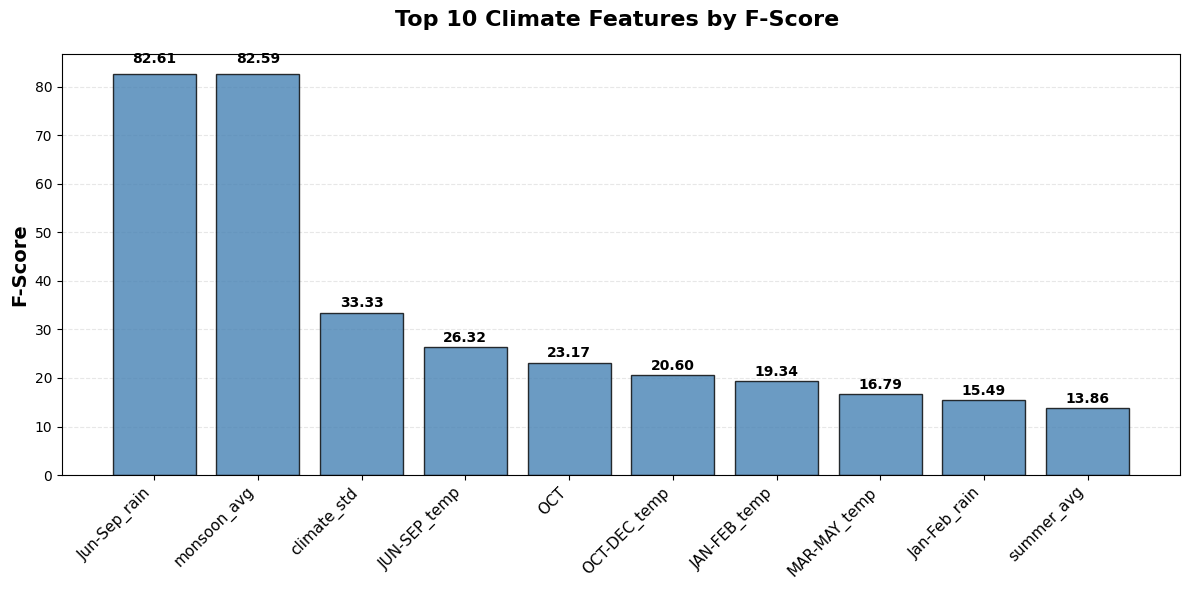


=== Detailed F-Score Analysis ===
Jun-Sep_rain             : F-Score = 82.6085
monsoon_avg              : F-Score = 82.5939
climate_std              : F-Score = 33.3327
JUN-SEP_temp             : F-Score = 26.3239
OCT                      : F-Score = 23.1704
OCT-DEC_temp             : F-Score = 20.5981
JAN-FEB_temp             : F-Score = 19.3395
MAR-MAY_temp             : F-Score = 16.7860
Jan-Feb_rain             : F-Score = 15.4895
summer_avg               : F-Score = 13.8561


In [ ]:
# ===================== F-SCORE BAR CHART =====================

# Plot F-scores
plt.figure(figsize=(12, 6))
bars = plt.bar(f_score_df['Feature'].head(10), f_score_df['F_Score'].head(10),
               color='steelblue', alpha=0.8, edgecolor='black')

# Customize the plot
# plt.xlabel("Climate Features", fontsize=14, fontweight='bold')
plt.ylabel("F-Score", fontsize=14, fontweight='bold')
plt.title("Top 10 Climate Features by F-Score ",
          fontsize=16, fontweight='bold', pad=20)

# Rotate x-axis labels for better readability
plt.xticks(rotation=45, ha='right', fontsize=11)

# Add value labels on top of bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + height*0.02,
             f'{height:.2f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

# Add grid
plt.grid(axis='y', alpha=0.3, linestyle='--')
plt.gca().set_axisbelow(True)

# Adjust layout
plt.tight_layout()
plt.show()

# Print feature details
print("\n=== Detailed F-Score Analysis ===")
for i, row in f_score_df.head(10).iterrows():
    print(f"{row['Feature']:25s}: F-Score = {row['F_Score']:.4f}")

In [ ]:
# ===================== 2. PREPARE DATA FOR CLUSTERING =====================

# Select features for clustering (F-score selected features)
fscore_features= ['Jun-Sep_rain', 'monsoon_avg', 'climate_std', 'JUN-SEP_temp', 'OCT', 'OCT-DEC_temp', 'JAN-FEB_temp', 'MAR-MAY_temp', 'Jan-Feb_rain', 'summer_avg']
# fscore_features = ['Jun-Sep', 'JAN-FEB', 'MAR-MAY', 'JUN-SEP', 'OCT-DEC', 'OCT', 'MAR', 'Jan-Feb', 'Mar-May', 'FEB']
print(f"\nFeatures used for clustering: {fscore_features}")

# Extract feature matrix
X = climate_features[fscore_features].copy()

# Handle missing values
X = X.fillna(X.mean())

# Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=fscore_features)

print(f"\nFeature matrix shape: {X_scaled_df.shape}")
print("Feature statistics after scaling:")
print(X_scaled_df.describe())


Features used for clustering: ['Jun-Sep_rain', 'monsoon_avg', 'climate_std', 'JUN-SEP_temp', 'OCT', 'OCT-DEC_temp', 'JAN-FEB_temp', 'MAR-MAY_temp', 'Jan-Feb_rain', 'summer_avg']

Feature matrix shape: (58, 10)
Feature statistics after scaling:
       Jun-Sep_rain   monsoon_avg   climate_std  JUN-SEP_temp           OCT  \
count  5.800000e+01  5.800000e+01  5.800000e+01  5.800000e+01  5.800000e+01   
mean  -7.895983e-17  6.675694e-16  2.847339e-16  3.269415e-15 -2.330511e-16   
std    1.008734e+00  1.008734e+00  1.008734e+00  1.008734e+00  1.008734e+00   
min   -2.399930e+00 -2.399572e+00 -2.609515e+00 -2.173372e+00 -1.704985e+00   
25%   -6.134616e-01 -6.132929e-01 -4.710916e-01 -6.020420e-01 -8.080705e-01   
50%    1.502770e-01  1.509663e-01  5.366334e-02 -2.125671e-01 -1.174361e-01   
75%    4.817618e-01  4.821153e-01  5.717746e-01  4.320809e-01  9.210434e-01   
max    2.144600e+00  2.144477e+00  2.464797e+00  3.010673e+00  2.194116e+00   

       OCT-DEC_temp  JAN-FEB_temp  MAR-MAY_


DETERMINING OPTIMAL NUMBER OF CLUSTERS


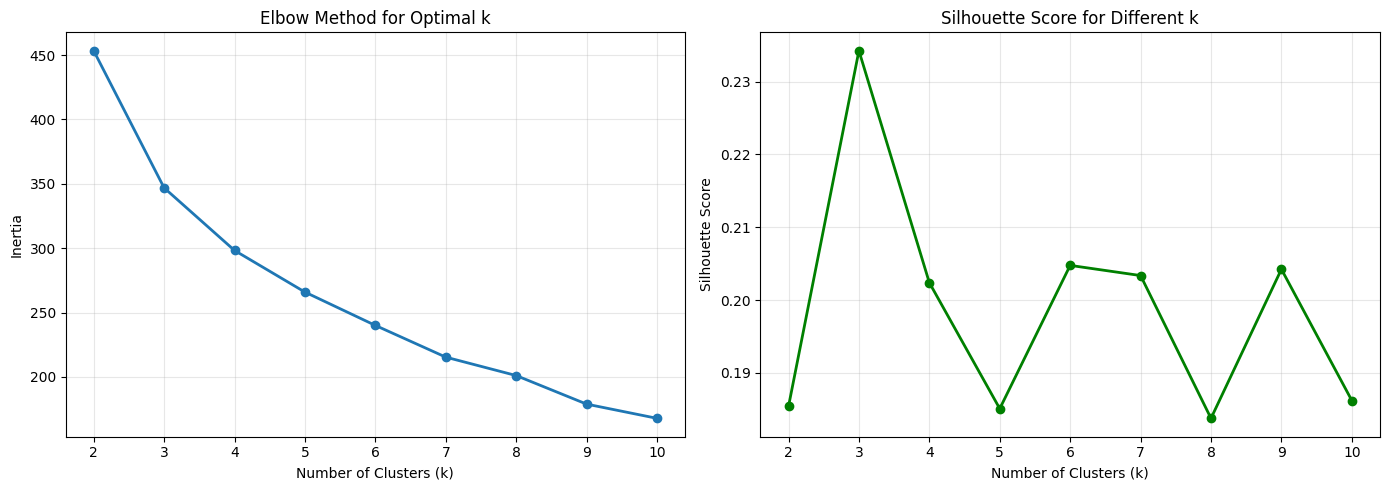

In [ ]:
# ===================== 3. DETERMINE OPTIMAL NUMBER OF CLUSTERS (ELBOW METHOD) =====================

print("\n" + "="*60)
print("DETERMINING OPTIMAL NUMBER OF CLUSTERS")
print("="*60)

# Elbow method
inertia = []
silhouette_scores = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, kmeans.labels_))

# Plot elbow curve
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(K_range, inertia, marker='o', linewidth=2)
axes[0].set_xlabel('Number of Clusters (k)')
axes[0].set_ylabel('Inertia')
axes[0].set_title('Elbow Method for Optimal k')
axes[0].grid(True, alpha=0.3)

axes[1].plot(K_range, silhouette_scores, marker='o', color='green', linewidth=2)
axes[1].set_xlabel('Number of Clusters (k)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score for Different k')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

